# Spår A
**Bakgrundshistoria:** En kund vill kunna göra grova värderingar av bostadsområden för att kunna planera investeringar och resurser. De vill kunna uppskatta bostadsvärdet baserat på områdets egenskaper.

**Uppdrag:** Bygg en modell som förutsäger median_house_value.

**Syfte:** Att kunna göra en rimlig värdeprognos och samtidigt förstå vilka faktorer som verkar hänga ihop med högre/lägre värde.

**För G:**

1) Dataförståelse & EDA (kort men relevant)
 Krav:
Visa datasetets storlek, datatyper och vilka features som finns.
Kontrollera saknade värden och beskriv kort hur du hanterar dem.
Minst 2 relevanta figurer/tabeller + kort tolkning.

2) Split + preprocessing
 Krav:
Dela datan i train och test.
Klassificering: använd stratifierad split (stratify) så att klasserna fördelas rimligt i train/test.
Preprocessing ska göras på ett sätt som undviker att testdata påverkar träningen.

3) Modellering
 Krav:
Skapa en baseline.
Träna minst två ytterligare modeller (totalt minst 3 inkl baseline).
Jämför modellerna med en tydlig utvärderingsmetod (t.ex. cross-validation eller valideringsupplägg).

4) Välj och optimera en modell
 Krav:
Välj en modell baserat på din jämförelse.
Optimera den valda modellen med hyperparameter-tuning (t.ex. GridSearchCV). Du väljer själv vilka parametrar som är relevanta
Beskriv kort vad du optimerade och vilken metric du optimerade mot.

5) Slutlig utvärdering på testdata + rekommendation
 Krav:
Utvärdera din slutliga modell på testdata och rapportera resultatet.
Välj minst en relevant metric och motivera valet:
Regression: t.ex. MAE eller RMSE
Klassificering: t.ex. F1 eller recall/precision
Sammanfatta resultat tydligt (tabell rekommenderas).
Skriv en kort rekommendation: vilken modell skulle du ta vidare och varför?

6) Rapport (PDF, 1–2 sidor)
 Krav:
Du ska lämna in en rapport enligt ramen under “Rapport – struktur”.

# Imports

In [19]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# 1. Loading Data, Cleaning Data and Simple EDA

## Loading Data

In [2]:
# Read housing.csv as pandas dataframe
housing_df = pd.read_csv("Data/housing.csv")

## Cleaning Data

In [3]:
print("-----Before cleaning")
print(housing_df.isna().sum())
#display(housing_df.describe())

# Fill empty values in total_bedrooms with the mean of total_bedrooms
housing_df["total_bedrooms"] = housing_df["total_bedrooms"].fillna(housing_df["total_bedrooms"].mean())

display(housing_df.describe())

print("\n-----After cleaning")
print(housing_df.isna().sum())

-----Before cleaning
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



-----After cleaning
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## Simple EDA

<AxesSubplot: >

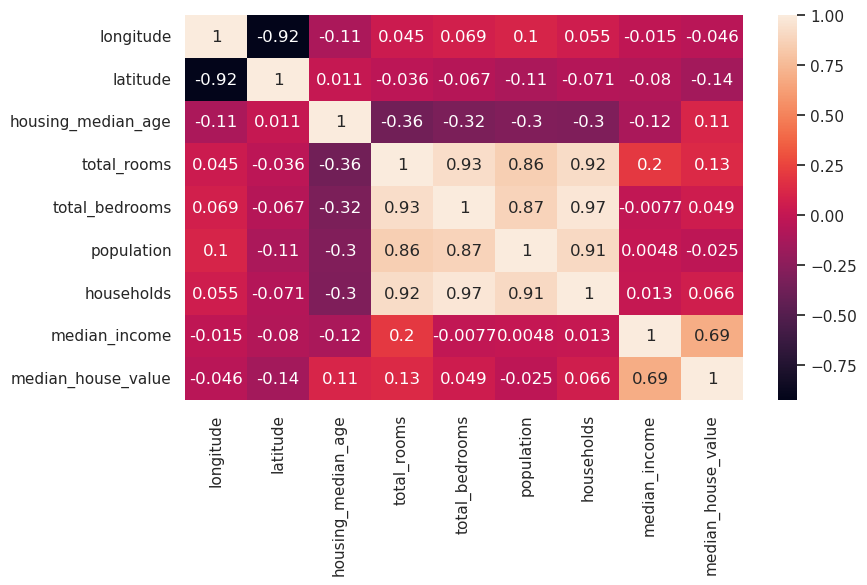

In [4]:
correlation_matrix = housing_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(correlation_matrix, annot=True, ax=ax)

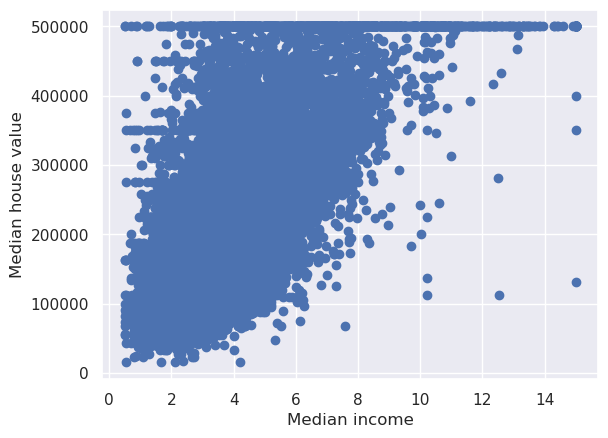

In [5]:
plt.scatter(housing_df["median_income"], housing_df["median_house_value"])
plt.xlabel("Median income")
plt.ylabel("Median house value")
plt.show()

### Graph interpretation
**Correlation matrix:** One can expect that more population results in more total rooms and bedrooms as well as households. The correlation matrix suggests this to be the case.

**Scatter plot:** The median house value increases sharply as median income increases slightly.

# 2. Split Data

In [6]:
# Get target column name and feature column names
target_col_name = "median_house_value"
feature_col_names = [col for col in housing_df.columns if col != target_col_name]

# Get corresponding data for target and features
x_full = housing_df[feature_col_names]
y_full = housing_df[target_col_name]

# Split data into 5 roughly equal quartiles
y_binned = pd.qcut(y_full, q=5, labels=False)

# Split into training and testing data for x and y
x_train, x_test, y_train, y_test = train_test_split(
    x_full,
    y_full,
    stratify=y_binned,
    test_size=0.2,
    random_state=17
)

print("Train shape: ", x_train.shape)
print("Test shape: ", x_test.shape)

Train shape:  (16512, 9)
Test shape:  (4128, 9)


## Cross Validation strategy

In [7]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=17)

## Evaluation function - From Class

In [8]:
def evaluate_regression_model(_y_true, _y_pred, _model_name: str) -> dict:
    """
    Evaluates a regression model with multiple normal metrics
    Returns a dictionary with RMSE, MAE, R2
    """
    
    rmse = root_mean_squared_error(_y_true, _y_pred)
    mae = mean_absolute_error(_y_true, _y_pred)
    r2 = r2_score(_y_true, _y_pred)

    return {"model name": _model_name, "rmse": rmse, "mae": mae, "r2": r2}

## Grid search function - From Class

In [9]:
def run_grid_search(_pipeline: Pipeline, _param_grid: dict, _model_name: str) -> GridSearchCV:
    """
    Runs GridSearchCV for a given pipeline and parameter grid
    Returns GridSearchCV object that contains:
    - best_params_
    - best_score_
    - best_estimator_
    """

    grid_search = GridSearchCV(
        estimator=_pipeline,
        param_grid=_param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv_strategy,
        n_jobs=-1
    )

    grid_search.fit(x_train, y_train)

    print(f"\n=== {_model_name} ===")
    print("Best CV RMSE: ", -grid_search.best_score_)
    print("Best params: ", grid_search.best_params_)

    return grid_search

### Preprocessing - help from ai using one hot encoding to eliminate the categorical columns

In [10]:
# Specify numeric and categorical columns
numeric_cols = x_train.select_dtypes(include=["float64", "int64"]).columns
categorical_cols = ['ocean_proximity']

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# 3. Models

### Baseline model

In [11]:
baseline_model = DummyRegressor(strategy="mean")

# FIT means: Learn from Training Data
baseline_model.fit(x_train, y_train)

# PREDICT means: Create Prediction from new Data
baseline_predictions_test = baseline_model.predict(x_test)

baseline_results = evaluate_regression_model(
    y_test,
    baseline_predictions_test,
    "Baseline (mean)"
)

baseline_results

{'model name': 'Baseline (mean)',
 'rmse': 114735.75702398372,
 'mae': 90732.08230785762,
 'r2': -2.9902302353113086e-05}

### Linear Regression

In [32]:
linear_pipeline = Pipeline([
    ("scaler", preprocessor),
    ("model", LinearRegression())
])

linear_grid = GridSearchCV(
        estimator=linear_pipeline,
        param_grid={},
        scoring="neg_root_mean_squared_error",
        cv=cv_strategy,
        n_jobs=-1
    )

linear_grid.fit(x_train, y_train)

print("Linear Regression - CV RMSE: ", -linear_grid.best_score_)

# Use the best estimator found by GridSearchCV
y_pred = linear_grid.best_estimator_.predict(x_test)
results = evaluate_regression_model(y_test, y_pred, "Linear Regression")
results

Linear Regression - CV RMSE:  68900.50183455252


{'model name': 'Linear Regression',
 'rmse': 68544.27891614445,
 'mae': 50081.48691860465,
 'r2': 0.6430907206928911}

### Random Forest

In [39]:
# --- Random Forest pipeline ---
r_forest_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=17))
])

r_forest_grid = GridSearchCV(
        estimator=r_forest_pipeline,
        param_grid={},
        scoring="neg_root_mean_squared_error",
        cv=cv_strategy,
        n_jobs=-1
    )

# --- Fit model ---
r_forest_grid.fit(x_train, y_train)
print("Random Forest Regression - CV RMSE: ", -r_forest_grid.best_score_)

# Use the best estimator found by GridSearchCV
y_pred = r_forest_grid.best_estimator_.predict(x_test)
results = evaluate_regression_model(y_test, y_pred, "Random Forest Regression")
results

Random Forest Regression - CV RMSE:  50122.58853904485


{'model name': 'Random Forest Regression',
 'rmse': 46407.961444225446,
 'mae': 30648.130278585268,
 'r2': 0.8363935585302051}

### Ridge

In [ ]:
ridge_pipeline = Pipeline([
    ("scaler", preprocessor),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.5, 1.0, 1.5, 10.0]#[0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16]
}

ridge_grid = run_grid_search(
    _pipeline=ridge_pipeline,
    _param_grid=ridge_param_grid,
    _model_name="Ridge Regression"
)


=== Ridge Regression ===
Best CV RMSE:  68900.6317208002
Best params:  {'model__alpha': 0.01}


### Elastic Net

In [14]:
elastic_pipeline = Pipeline([
    ("scaler", preprocessor),
    ("model", ElasticNet(max_iter=10000))
])

elastic_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}

elastic_grid = run_grid_search(
    _pipeline=elastic_pipeline,
    _param_grid=elastic_param_grid,
    _model_name="Elastic Regression"
)


=== Elastic Regression ===
Best CV RMSE:  68902.75751590278
Best params:  {'model__alpha': 0.001, 'model__l1_ratio': 0.9}


# 4. Choice of model and optimization

In [40]:
cv_results = []

cv_results.append({"model": "Linear Regression", "CV RMSE": -linear_grid.best_score_})
cv_results.append({"model": "Random Forest Regression", "CV RMSE": -r_forest_grid.best_score_})
cv_results.append({"model": "Ridge Regression", "CV RMSE": -ridge_grid.best_score_})
cv_results.append({"model": "Elastic Net Regression", "CV RMSE": -elastic_grid.best_score_})

cv_results_df = pd.DataFrame(cv_results).sort_values("CV RMSE")
cv_results_df

,model,CV RMSE
1,Random Forest Regression,50122.588539
0,Linear Regression,68900.501835
2,Ridge Regression,68900.631721
3,Elastic Net Regression,68902.757516


In [42]:
best_model_name = cv_results_df.iloc[0]["model"]
print("Best model according to CV: ", best_model_name)

best_estimator_lookup = {
    "Linear Regression": linear_grid.best_estimator_,
    "Random Forest Regression": r_forest_grid.best_estimator_,
    "Ridge Regression": ridge_grid.best_estimator_,
    "Elastic Net Regression": elastic_grid.best_estimator_,
}

best_model = best_estimator_lookup[best_model_name]
best_model

Best model according to CV:  Random Forest Regression


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ocean_proximity'])])),
                ('model', RandomForestRegressor(random_state=17))])